# Stroke Prediction Using Logistic Regression

## Project structure

1. Project objective  
2. Import libraries  
3. Load dataset and basic overview  
4. Exploratory data analysis  
   4.1 Quantitative variables
   
   4.2 Categorical variables
   
   4.3 Relationship between quantitative variables and stroke
   
   4.4 Relationship between categorical variables and stroke
   
   4.5 Possible confounding by age
   4.6 Initial clinical interpretation  
6. Data cleaning  
7. Preprocessing  
8. Train-test split  
9. Model development  
   8.1 Standard Logistic Regression  
   8.2 Balanced Logistic Regression  
10. Model evaluation  
   9.1 Model comparison  
   9.2 Threshold tuning  
11. Coefficient interpretation  
   10.1 Raw coefficients  
   10.2 Scaled coefficients  
   10.3 Caution about categorical coefficients  
12. Additional subgroup check: work_type  
13. Limitations  
14. Conclusion  
15. What I learned

## 1. Project objective

The objective of this project is to build and evaluate logistic regression models for stroke prediction using routinely available clinical variables. This is an exploratory educational project focused on clinical machine learning workflow, model evaluation in imbalanced data, and cautious interpretation of model outputs.

## 2. Import libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,roc_auc_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay

## 3. Load dataset and basic overview  


In [2]:
very_first_data = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
very_first_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
very_first_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
very_first_data.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
df=very_first_data.copy()
df = df.drop("id" , axis= 1)

In [7]:
quantitative_cols =["age","avg_glucose_level","bmi"]
cat_cols =['gender', 'hypertension', 'heart_disease',
       'ever_married', 'work_type', 'Residence_type', 'smoking_status']
target= "stroke"

## 4. Exploratory Data Analysis

### 4.1 Quantitative variables

In [8]:
df[quantitative_cols].corr()

,age,avg_glucose_level,bmi
age,1.000000,0.238171,0.333398
avg_glucose_level,0.238171,1.000000,0.175502
bmi,0.333398,0.175502,1.000000


In [9]:
quantitative_tables = dict()
for i, col in enumerate(quantitative_cols):
    list_temp =[]
    list_temp.append([df[col].mean(), df[col].std(),
                     df[col].max(), df[col].min(),
                    df[col].skew(),
                     df[col].isna().sum()])
    quantitative_tables[i] = list_temp
    


In [10]:
quantitative_data = [quantitative_tables[0][0],
quantitative_tables[1][0],
quantitative_tables[2][0]]

In [11]:
df_quantitative = pd.DataFrame(quantitative_data,
            columns = ["mean","std","max","min","skewness", "Nan"],
            index = quantitative_cols)

In [12]:
df_quantitative.to_csv("continuous_variables_summary.csv")

In [13]:
df_quantitative

,mean,std,max,min,skewness,Nan
age,43.226614,22.612647,82.00,0.08,-0.137059,0
avg_glucose_level,106.147677,45.283560,271.74,55.12,1.572284,0
bmi,28.893237,7.854067,97.60,10.30,1.055340,201


In [14]:
df["bmi"].isna().sum()

np.int64(201)

Text(0.5, 0.9, 'number of missing  BMI values is 201')

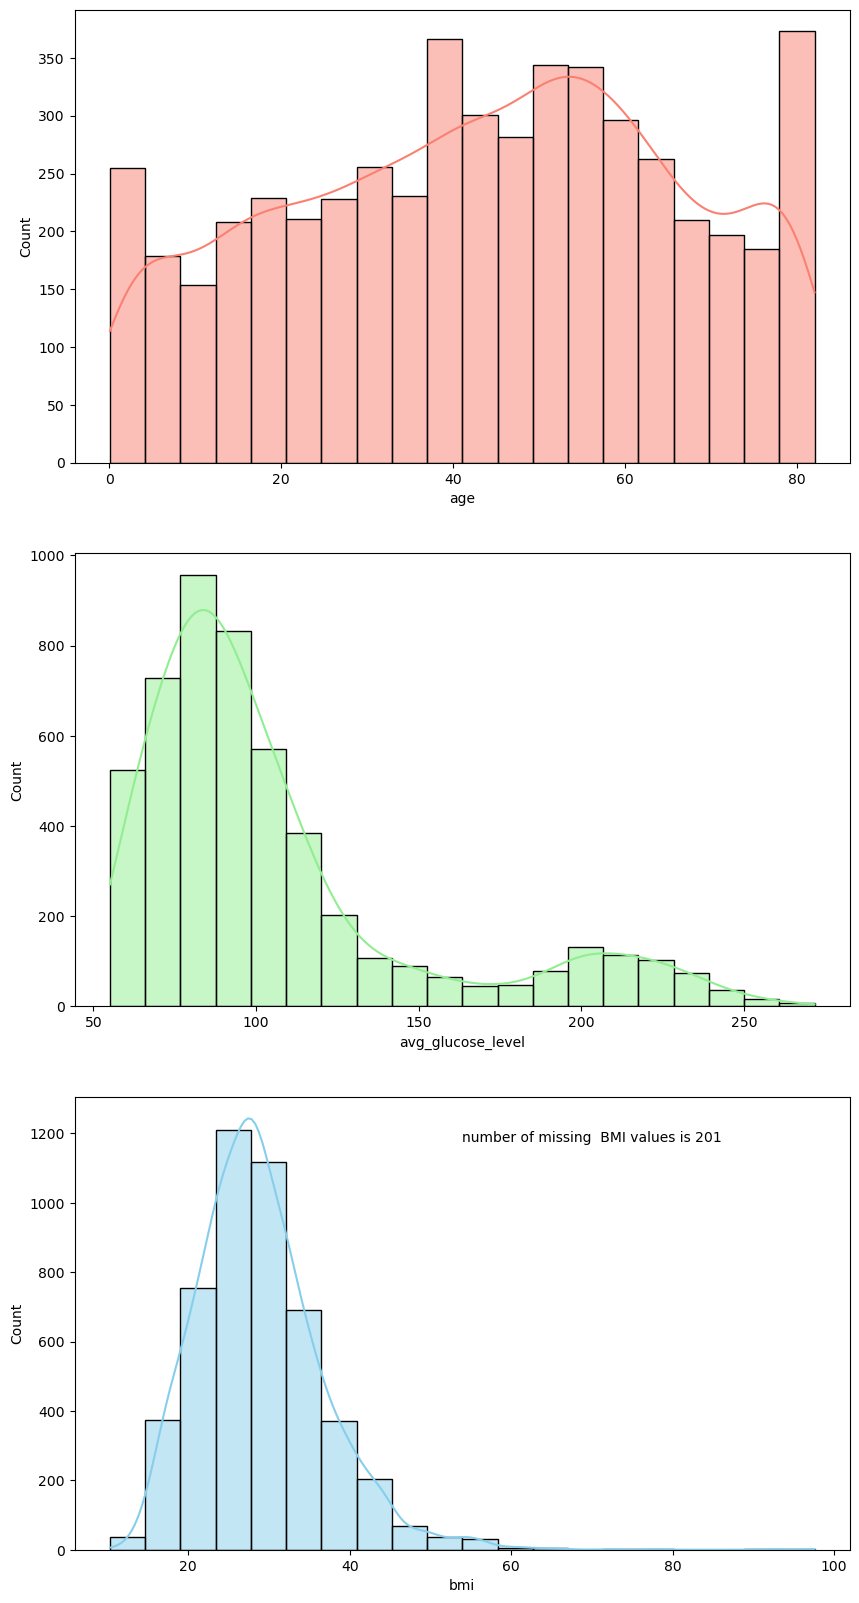

In [15]:
fig, axes= plt.subplots(3,1,figsize=(10,20))
sns.histplot(very_first_data["age"],ax=axes[0],bins=20,kde=True, color="salmon")
sns.histplot(very_first_data["avg_glucose_level"],ax=axes[1], bins=20, kde=True, color = "lightgreen")
sns.histplot(data=very_first_data, x="bmi",ax=axes[2], bins=20 , kde= True, color ="skyblue")
axes[2].text( 0.5, 0.9,f"number of missing  BMI values is {df["bmi"].isna().sum()}", transform = axes[2].transAxes )


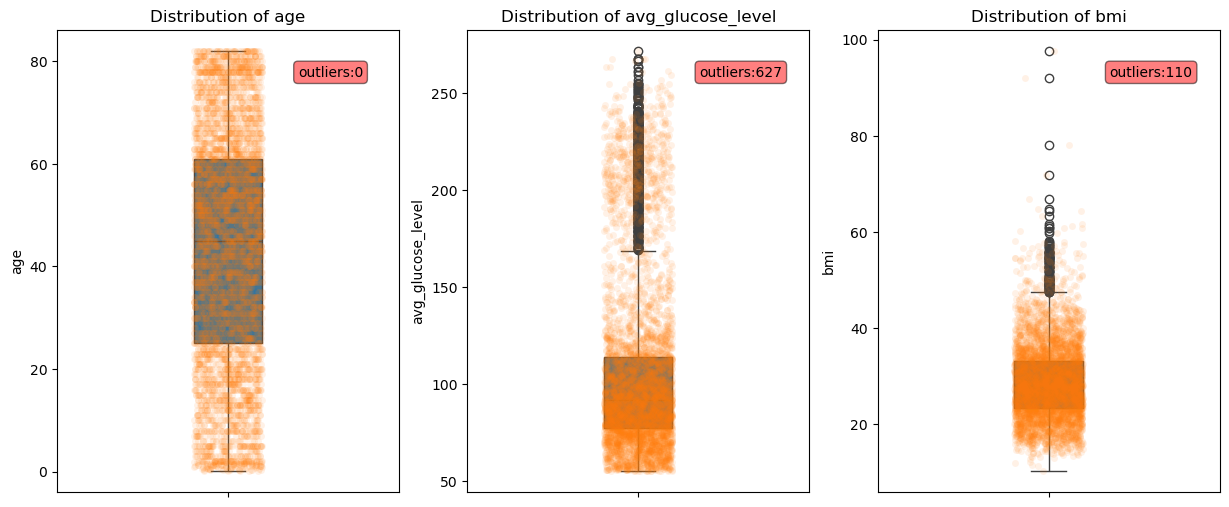

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,6))
for i, k in enumerate(quantitative_cols):
    axes[i].set_title(f"Distribution of {k}")
    sns.boxplot(data=df, ax=axes[i], y=k ,width=0.2)
    q1=df[k].quantile(0.25)
    q3=df[k].quantile(0.75)
    sns.stripplot(data=df, ax=axes[i], y=k, alpha=0.1 )
    IQR=q3-q1
    outliers = df[(df[k]<q1-1.5*IQR)|(df[k]>q3+1.5*IQR)]
    axes[i].text(0.8,0.9,f"outliers:{len(outliers)}",transform=axes[i].transAxes,
                bbox=dict(boxstyle="round",facecolor="red",alpha=0.5),ha="center")



### 4.2 Categorical variables

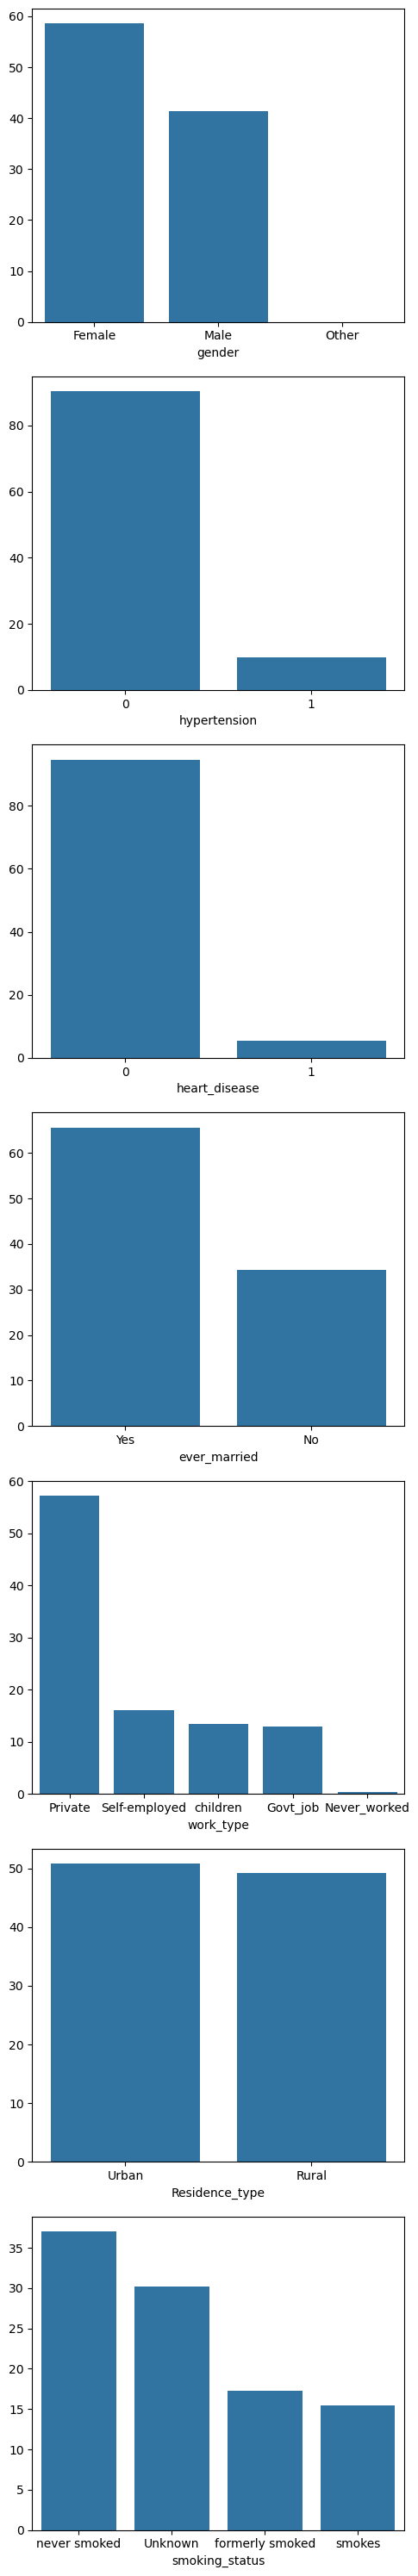

In [17]:
fig, axes = plt.subplots(len(cat_cols),1, figsize=(5,30))
for i, k in enumerate(cat_cols):
    quantitative_per = df[k].value_counts(normalize = True , dropna = False)*100
    sns.barplot(x=quantitative_per.index,y=quantitative_per.values ,ax=axes[i])
plt.tight_layout()
plt.show()


In [18]:
for col in cat_cols:
    print( "="*40)
    print(col)
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False) * 100)
    print(df[col].isna().sum())

gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: proportion, dtype: float64
0
hypertension
hypertension
0    4612
1     498
Name: count, dtype: int64
hypertension
0    90.254403
1     9.745597
Name: proportion, dtype: float64
0
heart_disease
heart_disease
0    4834
1     276
Name: count, dtype: int64
heart_disease
0    94.598826
1     5.401174
Name: proportion, dtype: float64
0
ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
ever_married
Yes    65.616438
No     34.383562
Name: proportion, dtype: float64
0
work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
work_type
Private          57.240705
Self-employed    16.027397
children         13.444227
Govt_job         12.857143
Never_worked      0.430528
Name: proportion, dtype: float64
0
Residence_type
R

### 4.3 Quantitative variables by stroke status

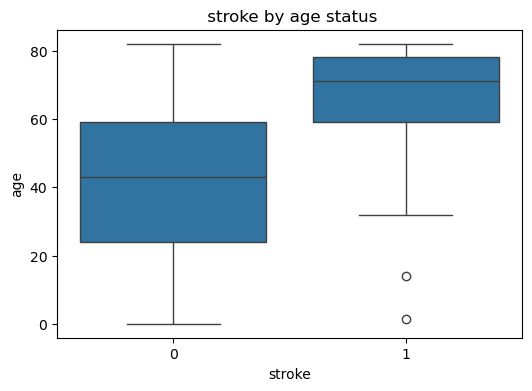

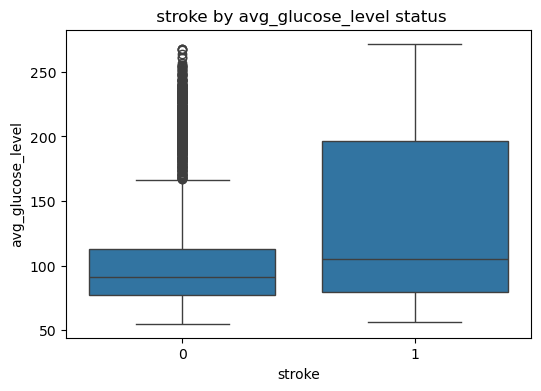

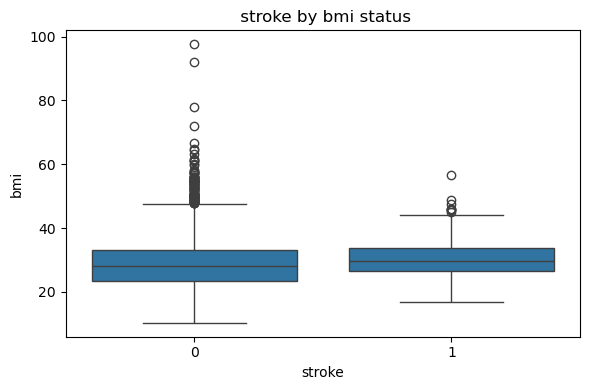

In [19]:
for col in quantitative_cols:
    plt.figure(figsize = (6,4))
    sns.boxplot(data = df , y = col, x = "stroke")
    plt.title(f' stroke by {col} status')
plt.tight_layout()

### 4.4 Categorical variables and stroke rate

In [20]:
for col in cat_cols:
    print("\n", "="*40)
    print(f"Stroke rate by {col}")
    print(df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100)


Stroke rate by gender
gender
Male      5.106383
Female    4.709419
Other     0.000000
Name: stroke, dtype: float64

Stroke rate by hypertension
hypertension
1    13.253012
0     3.967910
Name: stroke, dtype: float64

Stroke rate by heart_disease
heart_disease
1    17.028986
0     4.178734
Name: stroke, dtype: float64

Stroke rate by ever_married
ever_married
Yes    6.561288
No     1.650541
Name: stroke, dtype: float64

Stroke rate by work_type
work_type
Self-employed    7.936508
Private          5.094017
Govt_job         5.022831
children         0.291121
Never_worked     0.000000
Name: stroke, dtype: float64

Stroke rate by Residence_type
Residence_type
Urban    5.200308
Rural    4.534606
Name: stroke, dtype: float64

Stroke rate by smoking_status
smoking_status
formerly smoked    7.909605
smokes             5.323194
never smoked       4.756871
Unknown            3.044041
Name: stroke, dtype: float64


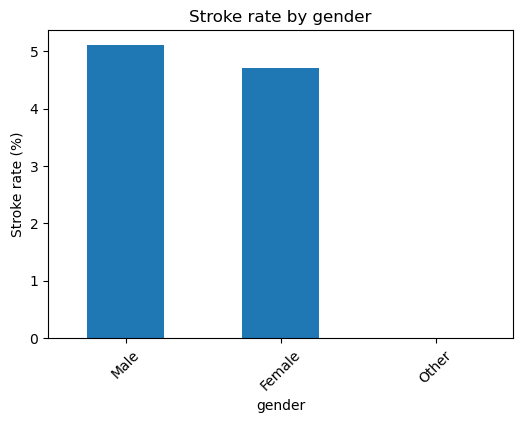

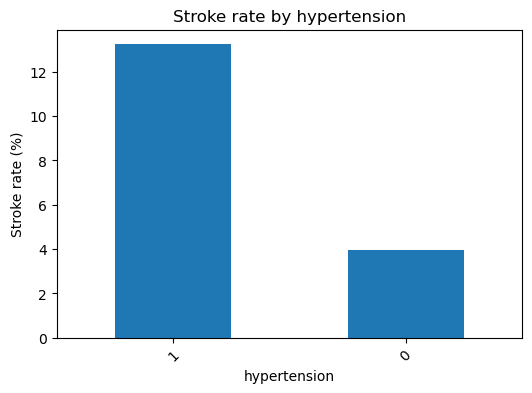

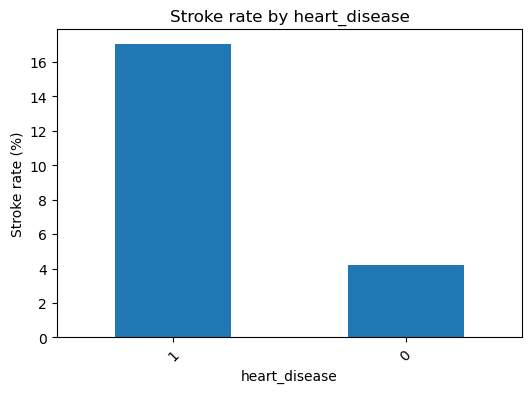

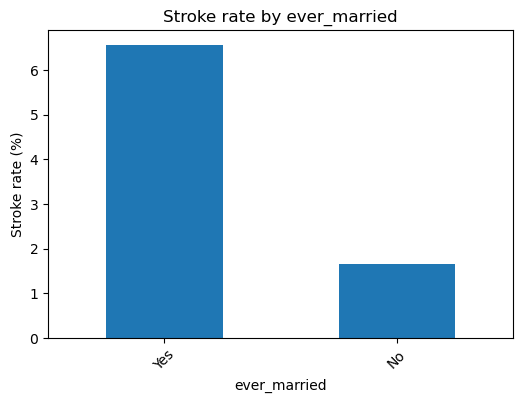

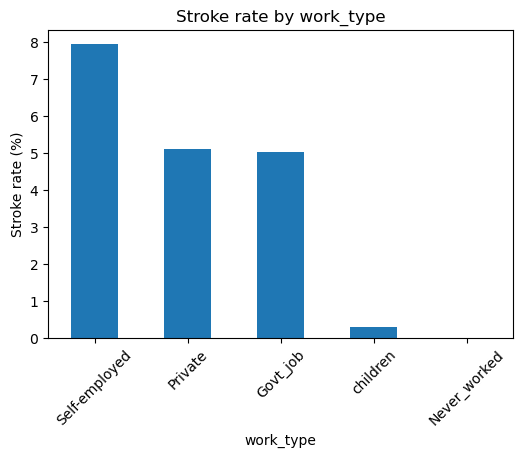

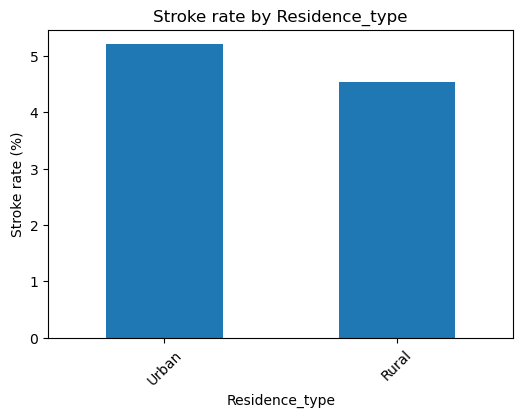

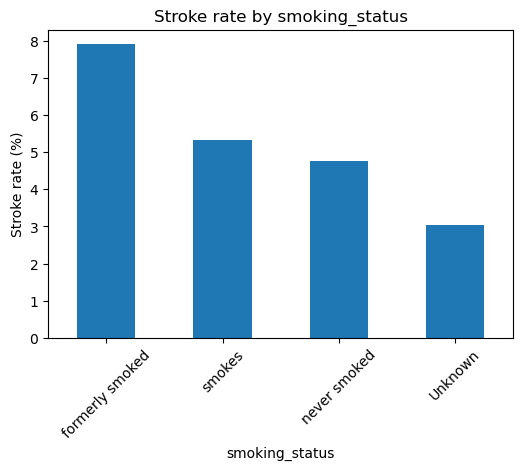

In [21]:
for col in cat_cols:
    stroke_rate = df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    
    plt.figure(figsize=(6, 4))
    stroke_rate.plot(kind="bar")
    plt.title(f"Stroke rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Stroke rate (%)")
    plt.xticks(rotation=45)
    plt.show()

### 4.5 Possible confounding by age

The crude stroke rate appeared higher among married participants. However, this association may be confounded by age, because married participants were older on average.

<class 'pandas.core.series.Series'>


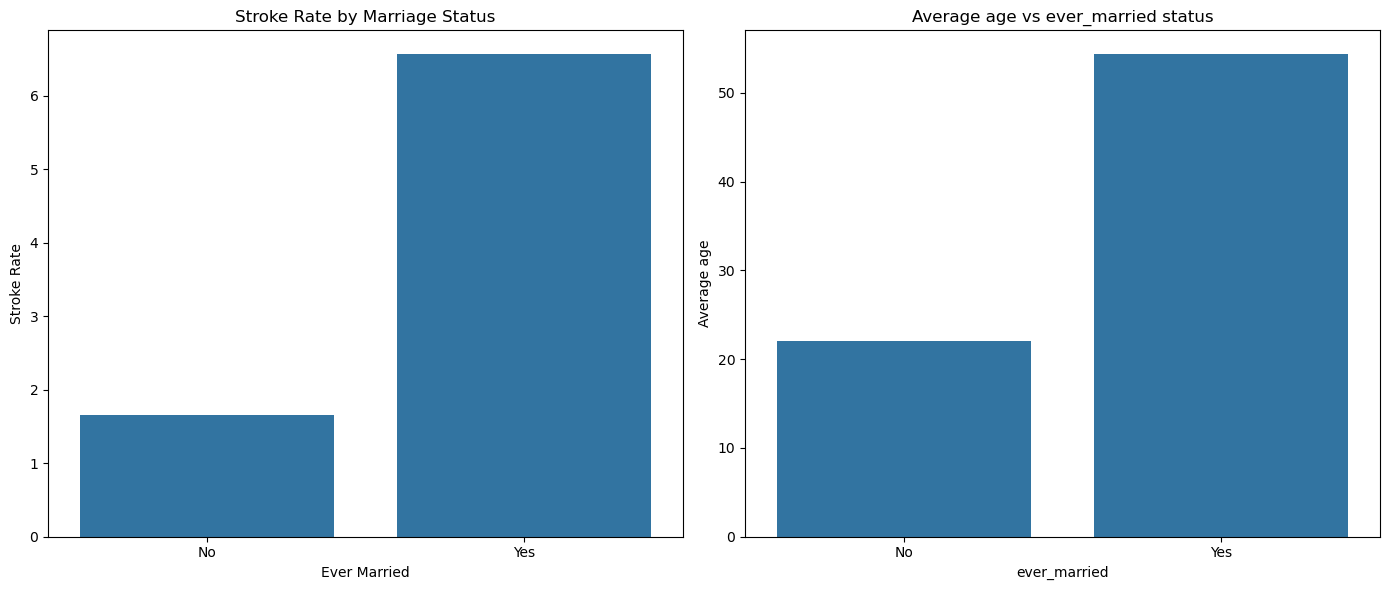

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

marriage_stroke = df.groupby('ever_married')['stroke'].mean()*100
print(type(marriage_stroke))
sns.barplot(x = marriage_stroke.index , y= marriage_stroke.values ,ax=axes[0] )
axes[0].set_title('Stroke Rate by Marriage Status')
axes[0].set_xlabel('Ever Married')
axes[0].set_ylabel('Stroke Rate')
age_married = df.groupby('ever_married')['age'].mean()
sns.barplot(x=age_married.index, y=age_married.values, ax=axes[1])
axes[1].set_title('Average age vs ever_married status')
axes[1].set_xlabel('ever_married')
axes[1].set_ylabel('Average age')
plt.tight_layout()
plt.show()


In [23]:
for col in cat_cols:
    print("\n", "="*40)
    print(col)
    print(pd.crosstab(df[col], df["stroke"], normalize="index") * 100)


gender
stroke           0         1
gender                      
Female   95.290581  4.709419
Male     94.893617  5.106383
Other   100.000000  0.000000

hypertension
stroke                0          1
hypertension                      
0             96.032090   3.967910
1             86.746988  13.253012

heart_disease
stroke                 0          1
heart_disease                      
0              95.821266   4.178734
1              82.971014  17.028986

ever_married
stroke                0         1
ever_married                     
No            98.349459  1.650541
Yes           93.438712  6.561288

work_type
stroke                  0         1
work_type                          
Govt_job        94.977169  5.022831
Never_worked   100.000000  0.000000
Private         94.905983  5.094017
Self-employed   92.063492  7.936508
children        99.708879  0.291121

Residence_type
stroke                  0         1
Residence_type                     
Rural           95.465394  4.5346

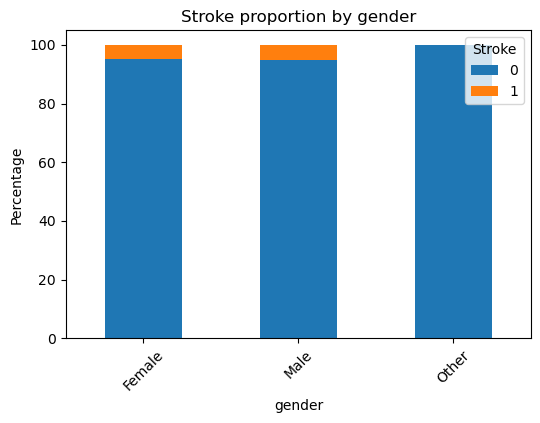

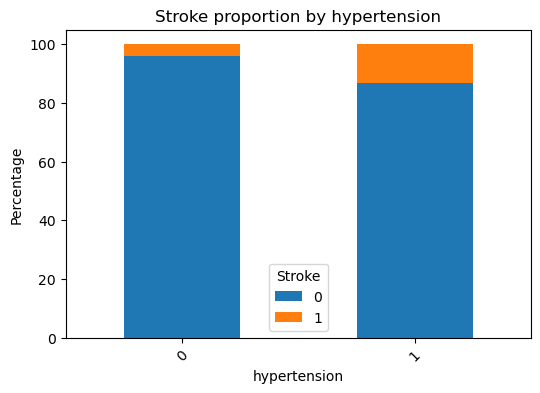

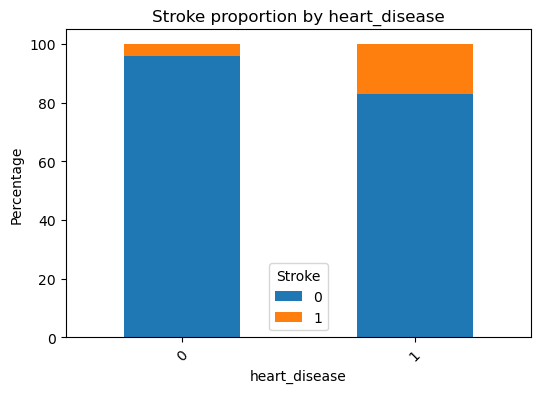

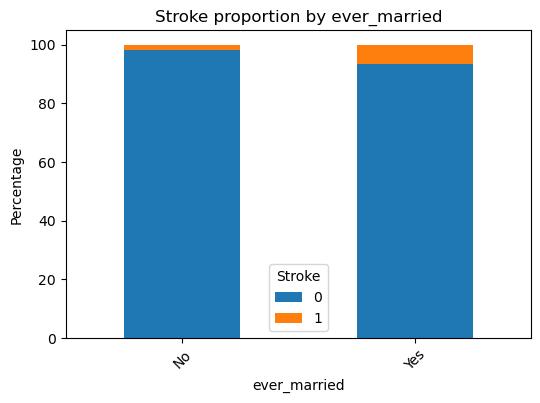

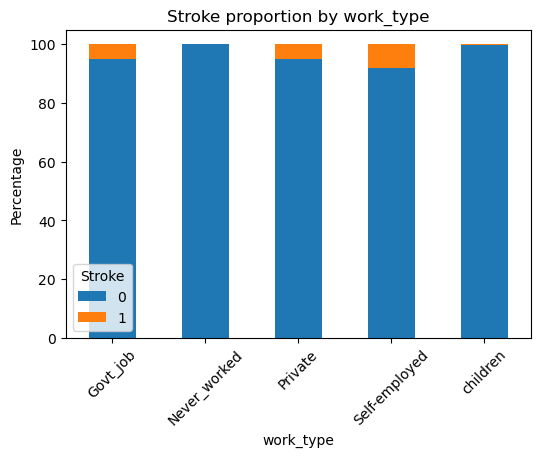

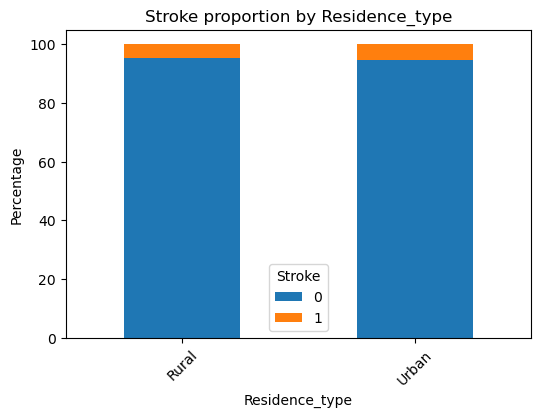

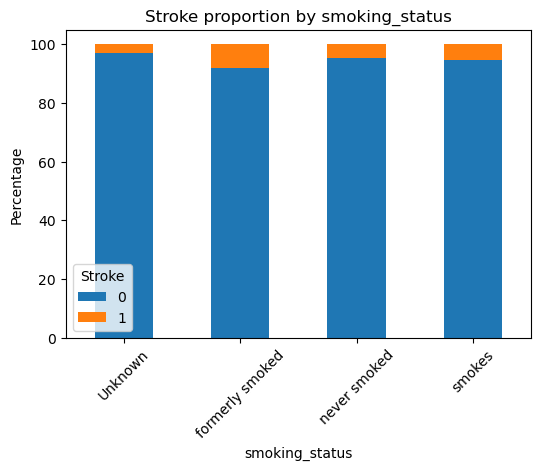

In [24]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df["stroke"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, figsize=(6, 4))
    plt.title(f"Stroke proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Stroke")
    plt.show()

### 4.6 Initial clinical interpretation

Initial EDA showed that stroke cases were relatively rare, indicating class imbalance. Stroke rate appeared higher among individuals with hypertension and heart disease. Married participants also showed a higher crude stroke rate; however, this may be confounded by age, since married individuals were older on average. BMI contained missing values and required imputation before model training.

## 5. Data cleaning

In this section, irrelevant identifiers were removed, rare categories were handled, and missing BMI values were imputed.

In [25]:
df_clean = df.copy()

In [26]:
temp = {}
for col in df_clean.columns:
    temp [col] = [df_clean[col].isna().sum()]
nan_values_count = pd.DataFrame(temp ).T
print(nan_values_count)

                     0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                201
smoking_status       0
stroke               0


Only BMI had missing values. Because BMI was right-skewed, median imputation was used.

In [27]:
df_clean = df_clean[df_clean["gender"]!="Other"].reset_index(drop = True)

In [28]:
df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())

In [29]:
X= df_clean.drop("stroke" , axis = 1)

In [30]:
y = df_clean["stroke"]

## 6. Preprocessing

Categorical variables were encoded using one-hot encoding. Binary variables such as hypertension and heart_disease were already coded as 0/1 and were kept unchanged.

In [31]:
x= pd.get_dummies(X,drop_first=True)

## 7. Train-test split

The dataset was split into training and test sets using stratification to preserve the proportion of stroke cases in both sets.

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2 ,
random_state=42, stratify = y)
                                                    

## 8. Model development

### 8.1 Standard Logistic Regression

In [33]:
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(x_train, y_train)
y_pred = log_model.predict(x_test)
y_prob = log_model.predict_proba(x_test)[:,1]

print(confusion_matrix(y_test, y_pred))
print(" -- "*25)
print(classification_report(y_test, y_pred))
print(" -- "*25)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[972   0]
 [ 49   1]]
 --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  -- 
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

 --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  -- 
ROC-AUC: 0.8394238683127572


The standard logistic regression model showed high accuracy but very poor sensitivity for stroke detection. This suggests that the model mostly predicted the majority class, which is no stroke.

### 8.2 Balanced Logistic Regression

Because stroke cases were rare, a balanced logistic regression model was also trained using class_weight="balanced".

In [34]:
log_model_balanced = LogisticRegression( max_iter = 1000, class_weight="balanced")
log_model_balanced.fit(x_train, y_train)
y_pred_balanced = log_model_balanced.predict(x_test)
y_prob_balanced = log_model_balanced.predict_proba(x_test)[:,1]

In [35]:
print(confusion_matrix(y_test, y_pred_balanced))
print(" -- " *25)
print(classification_report(y_test, y_pred_balanced))
print(" -- " *25)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

[[715 257]
 [ 10  40]]
 --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  -- 
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

 --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  --  -- 
ROC-AUC: 0.839156378600823


## 9 Model Evaluation
###   9.1 Model comparison  


In [36]:
def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [37]:
results = []
results.append(evaluate_model(log_model,x_test,y_test,"Logistic Regression"))
results.append(evaluate_model(log_model_balanced,x_test,y_test,"Logistic Regression Balanced"))


In [38]:
results_df = pd.DataFrame(results)
results_df.round(3)

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.952,1.000,0.02,1.000,0.039,0.839,972,0,49,1
1,Logistic Regression Balanced,0.739,0.135,0.80,0.736,0.231,0.839,715,257,10,40


The standard logistic regression model achieved high accuracy but had very poor sensitivity for stroke detection, showing that accuracy alone is misleading in this imbalanced dataset. The balanced logistic regression model improved sensitivity substantially and reduced false negatives, but this came at the cost of more false-positive predictions. Therefore, the balanced model is more suitable for an exploratory screening setting, while its low precision limits its use as a standalone diagnostic tool.

### 9.2 Threshold tuning

The model produces a probability of stroke for each patient. Changing the classification threshold changes the balance between sensitivity and specificity. Lower thresholds increase sensitivity but also increase false positives.

In [39]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 , 1]
threshold_results= list()
for threshold in thresholds:
    y_predic_balanced_thre = (y_prob_balanced>=threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_predic_balanced_thre).ravel()
    threshold_results.append({
    "Threshold": threshold,
    "Accuracy": accuracy_score(y_test, y_predic_balanced_thre),
    "Precision": precision_score(y_test, y_predic_balanced_thre, zero_division=0),
    "Recall/Sensitivity": recall_score(y_test, y_predic_balanced_thre),
    "Specificity": tn / (tn + fp),
    "F1-score": f1_score(y_test, y_predic_balanced_thre, zero_division=0),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
})

In [40]:
threshold_results_df = pd.DataFrame(threshold_results)

In [41]:
threshold_results_df.round(3)

,Threshold,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,TN,FP,FN,TP
0,0.0,0.049,0.049,1.00,0.000,0.093,0,972,0,50
1,0.1,0.397,0.074,0.98,0.367,0.137,357,615,1,49
2,0.2,0.513,0.081,0.86,0.495,0.147,481,491,7,43
3,0.3,0.597,0.094,0.84,0.584,0.169,568,404,8,42
4,0.4,0.668,0.113,0.84,0.659,0.199,641,331,8,42
5,0.5,0.739,0.135,0.80,0.736,0.231,715,257,10,40
6,0.6,0.806,0.170,0.76,0.809,0.277,786,186,12,38
7,0.7,0.844,0.199,0.72,0.851,0.312,827,145,14,36
8,0.8,0.899,0.243,0.50,0.920,0.327,894,78,25,25
9,0.9,0.938,0.259,0.14,0.979,0.182,952,20,43,7


Threshold tuning showed a clear trade-off between sensitivity and false positive rate. Lower thresholds increased sensitivity and reduced false negatives but produced more false positives. A threshold of 0.5 achieved high sensitivity for stroke detection, while a threshold of 0.6 provided a more balanced trade-off by substantially reducing false positives with only a small increase in false negatives. Therefore, threshold 0.6 may be considered a clinically more balanced operating point in this exploratory analysis.

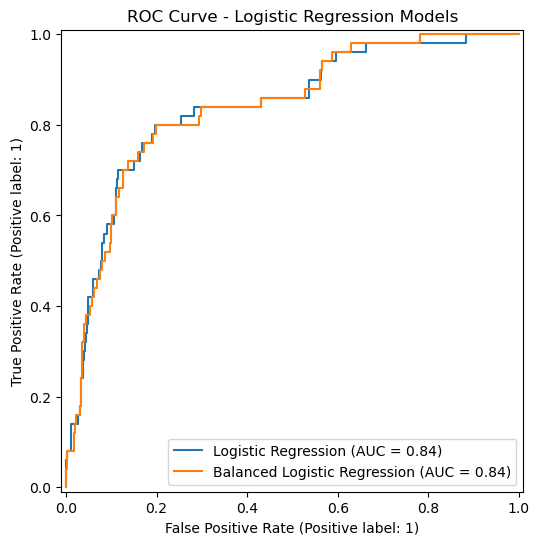

In [42]:

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(
    log_model,
    x_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    log_model_balanced,
    x_test,
    y_test,
    ax=ax,
    name="Balanced Logistic Regression"
)

ax.set_title("ROC Curve - Logistic Regression Models")
plt.show()

## 10. Coefficient interpretation

### 10.1 Raw coefficients

Raw logistic regression coefficients were first examined. However, because numerical variables had different scales, raw coefficients were not considered fully comparable.

In [43]:
coef_dict = {
    "features":x_train.columns,
    "coefficient" : log_model_balanced.coef_[0],
    
}

In [44]:
coef_df = pd.DataFrame(coef_dict)

In [45]:
coef_df["Abs_coefficient"] = coef_df["coefficient"].abs()

In [46]:
coef_df=coef_df.sort_values("Abs_coefficient",ascending = False)

In [47]:
coef_df

,features,coefficient,Abs_coefficient
10,work_type_children,0.890107,0.890107
1,hypertension,0.625678,0.625678
14,smoking_status_smokes,0.287172,0.287172
13,smoking_status_never smoked,-0.234990,0.234990
9,work_type_Self-employed,-0.211207,0.211207
11,Residence_type_Urban,0.173907,0.173907
6,ever_married_Yes,-0.171538,0.171538
7,work_type_Never_worked,-0.145706,0.145706
2,heart_disease,0.138007,0.138007
5,gender_Male,-0.132785,0.132785


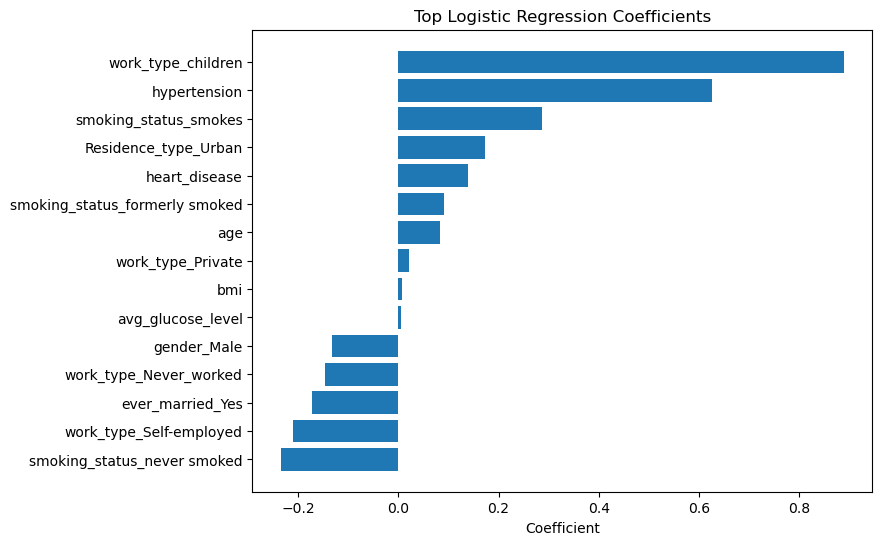

In [48]:
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef["features"], top_coef["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Logistic Regression Coefficients")
plt.show()

### 10.2 Scaled coefficients

To make numerical variables more comparable, age, average glucose level, and BMI were standardized before refitting the balanced logistic regression model.

In [49]:
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
scaler = StandardScaler()
x_train_scaled[quantitative_cols] = scaler.fit_transform(x_train_scaled[quantitative_cols])
x_test_scaled[quantitative_cols] = scaler.transform(x_test_scaled[quantitative_cols])
log_model_balanced_scaled = LogisticRegression(max_iter = 1000, class_weight = "balanced")
log_model_balanced_scaled.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [50]:
coef_scaled_df = pd.DataFrame({
    "Features" : x_train_scaled.columns,
    "Coefficient" : log_model_balanced_scaled.coef_[0]
})

In [51]:
coef_scaled_df["Abs_Coefficient"]= coef_scaled_df["Coefficient"].abs()
coef_scaled_df = coef_scaled_df.sort_values("Abs_Coefficient", ascending = False)

In [52]:
top_coef = coef_scaled_df.head(15).sort_values("Coefficient")

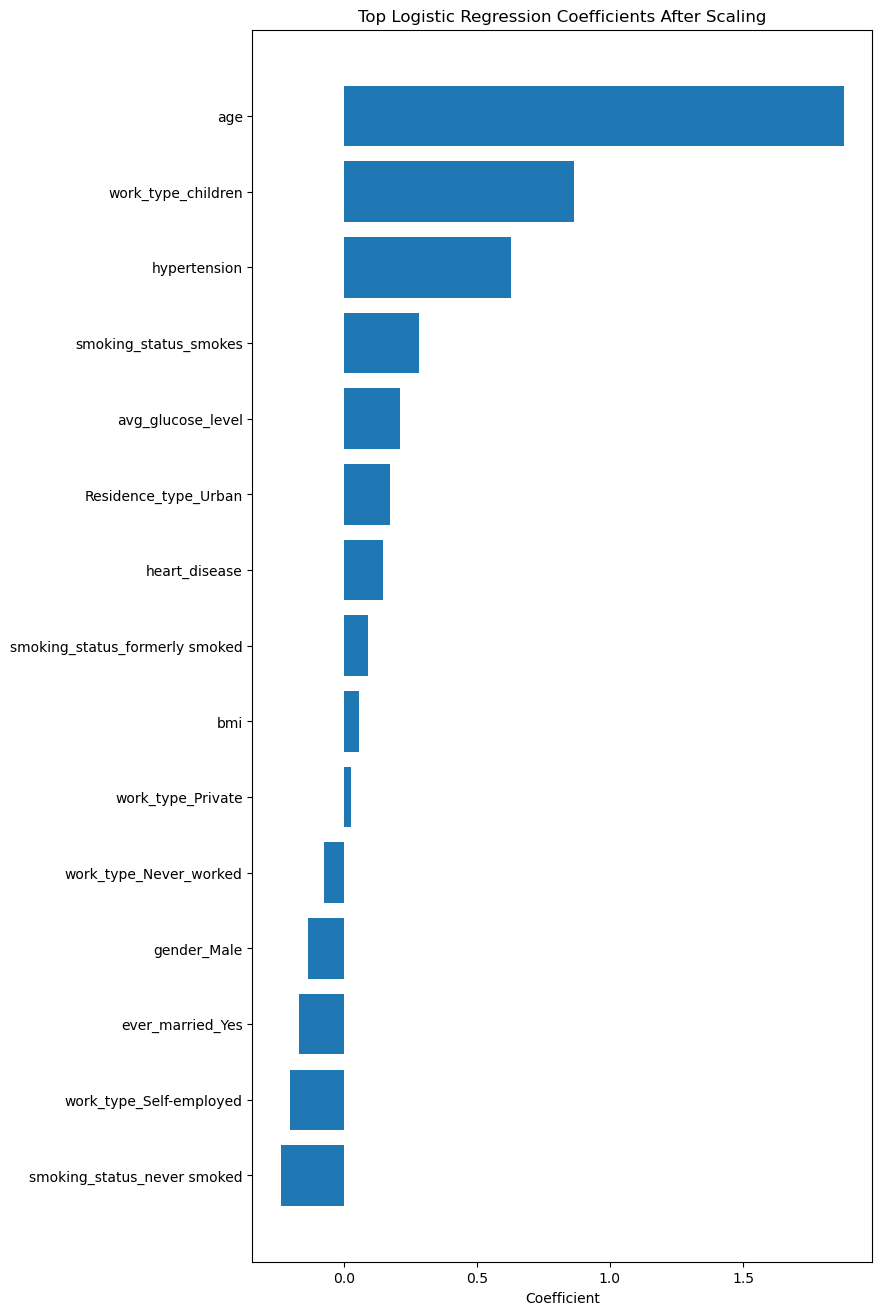

In [53]:
plt.figure(figsize=(8,16))
plt.barh(top_coef["Features"], top_coef["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Logistic Regression Coefficients After Scaling")
plt.show()

### 10.3 Caution about categorical coefficients

Although age became the most clinically plausible top coefficient after scaling, some categorical coefficients required cautious interpretation.

Although work_type_children appeared among the top coefficients, this should not be interpreted as children having higher stroke risk. This variable is strongly related to age and may be unstable due to the small number of stroke cases in this subgroup. Therefore, age is considered the more clinically meaningful predictor.

## 11. Additional subgroup check: work_type

Because work_type_children appeared among the larger coefficients, the crude stroke frequency and stroke rate by work_type were checked.

In [54]:
pd.crosstab(df_clean["work_type"], df_clean["stroke"])

stroke,0,1
work_type,,
Govt_job,624,33
Never_worked,22,0
Private,2775,149
Self-employed,754,65
children,685,2


In [55]:
(df_clean.groupby("work_type")["stroke"].mean() * 100).sort_values(ascending=False)

work_type
Self-employed    7.936508
Private          5.095759
Govt_job         5.022831
children         0.291121
Never_worked     0.000000
Name: stroke, dtype: float64

The crude subgroup analysis showed that the children category had a very low stroke rate, with only a small number of stroke cases. Therefore, the coefficient for work_type_children should not be interpreted as evidence of increased stroke risk in children. This finding is likely influenced by reference-category coding, class weighting, correlation with age, and small subgroup size.

### 12 Limitations:
 1. This project used a publicly available dataset with limited information about data collection and sampling methods.
 2. The dataset was highly imbalanced, with relatively few stroke cases.
 3. The model was evaluated only using an internal train-test split and no external validation was performed.
 4. Important clinical variables such as medications, laboratory values, imaging findings, atrial fibrillation, and prior stroke history were not available.
 5. Therefore, this model should be interpreted as an educational and exploratory project, not as a clinical diagnostic tool.

## 13  Conclusion
In this exploratory machine learning project, logistic regression models were developed to predict stroke using routinely available clinical variables. The standard logistic regression model showed misleadingly high accuracy but failed to identify most stroke cases. Using class weighting improved sensitivity and reduced false negatives, highlighting the importance of addressing class imbalance in medical prediction tasks. Overall, this project demonstrates a basic clinical machine learning workflow, including EDA, preprocessing, model training, evaluation, threshold analysis, and clinical interpretation.

## 14 What I learned

This project helped demonstrate several important principles in clinical machine learning:

1. Accuracy can be misleading in imbalanced medical datasets.
2. Sensitivity/recall is especially important when missing true disease cases is clinically harmful.
3. Class weighting can improve detection of the minority class but may increase false positives.
4. Threshold selection changes the balance between sensitivity and specificity.
5. Logistic regression coefficients require careful interpretation, especially when variables have different scales or categorical variables are reference-coded.